$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega (L_0 + \frac{L_J}{\cos{2\pi\phi}})}{\frac{1}{i\omega C_0} + i\omega (L_0 + \frac{L_J}{\cos{2\pi\phi}})}
$$
$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega L_0}{\frac{1}{i\omega C_0} + i\omega L_0}
$$
$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega L_0}{\frac{1}{i\omega C_0} + i\omega L_0}\left(\frac{i\omega C_0}{i\omega C_0}\right) = \frac{i\omega L_0}{1 - \omega^2C_0L_0} = \frac{i\omega L_0}{1 - (\omega/\omega_0)^2}
$$
$$
\omega_0 = \frac{1}{\sqrt{L_0C_0}}
$$
$$
Z_{\Sigma} = \frac{1}{i\omega C_{in}} + \frac{i\omega L_0}{1 - \omega^2C_0L_0} = \frac{1}{i\omega C_{in}} + \frac{i\omega L_0}{1 - (\omega/\omega_0)^2}
$$

In [4]:
# load needed python libraries matplotlib, numpy, and scikit-rf
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
import json
from skrf.media import *
from skrf import Frequency
from scipy.optimize import curve_fit

In [6]:
data_corrected = rf.read_all('jpa-nopump-scan2-s1p-corrected')

In [8]:
fghz = data_corrected['trace0'].f/1e9
file_object = open("biaswave.json", "r")
period = 1.85
biaswave = json.loads(file_object.read())
file_object.close()
biaswave = np.array(biaswave)
phiwave = biaswave/period

In [34]:
def jpa_complex(frequencyghz, CinpF, C0pF, L0pH, fghz_360):
    Cin = CinpF*1e-12
    C0 = C0pF*1e-12
    L0 = L0pH*1e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cin)) + (1j*omega*L0)/(1 - omega*omega*C0*L0)
    s_jpa = (50 - Z_jpa)/(50 + Z_jpa)
    s_jpa = s_jpa*np.exp(-1j*2*np.pi*frequencyghz/fghz_360)    
    return -s_jpa # this minus sign is suspect, i have no idea why it's here

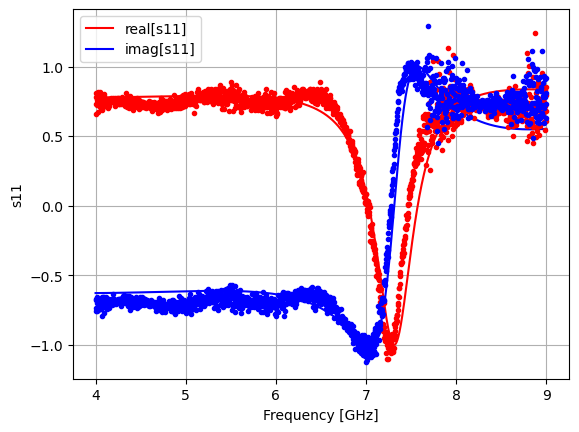

In [53]:
f0ghz_360_data = 2.3
f0ghz_360_theory = -21
Cinguess = 1 #  pF
C0guess = 5.2 # pF
L0guess = 88 #  pH


unwrapped_s = np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace460'].s[:,0,0]

plt.plot(fghz,np.real(jpa_complex(fghz,Cinguess,C0guess,L0guess,f0ghz_360_theory)),"red")
plt.plot(fghz,np.imag(jpa_complex(fghz,Cinguess,C0guess,L0guess,f0ghz_360_theory)),"blue")
plt.plot(fghz,np.real(unwrapped_s),'.',color="red")
plt.plot(fghz,np.imag(unwrapped_s),'.',color="blue")
plt.grid()
#plt.xlim(4,8)
plt.xlabel("Frequency [GHz]")
plt.ylabel("s11")
plt.legend(['real[s11]','imag[s11]'])

In [188]:
unwrapped_s = np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace460'].s[:,0,0]
unwrapped_s_ri_concat = np.concatenate((np.real(unwrapped_s),np.imag(unwrapped_s)))
fghzfghz = np.concatenate((fghz,fghz))


In [67]:
fghzfghz[0:1601]

array([4.   , 4.003, 4.006, ..., 8.994, 8.997, 9.   ])

In [69]:
def jpa_complex_concat(frequencyghzconcat, CinpF, C0pF, L0pH, fghz_360):
    halfnumber = int(len(frequencyghzconcat)/2)
    frequencyghz = frequencyghzconcat[0:halfnumber]
    Cin = CinpF*1e-12
    C0 = C0pF*1e-12
    L0 = L0pH*1e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cin)) + (1j*omega*L0)/(1 - omega*omega*C0*L0)
    s_jpa = (50 - Z_jpa)/(50 + Z_jpa)
    s_jpa = -s_jpa*np.exp(-1j*2*np.pi*frequencyghz/fghz_360)
    s_jpa_concat = np.concatenate((np.real(s_jpa),np.imag(s_jpa)))
    return s_jpa_concat # this minus sign is suspect, i have no idea why it's here

Text(0.5, 1.0, 'Cin = 1.2 pF, C0 = 5.96 pF, L0 = 78.695 pH, f_360 = -19.077 GHz')

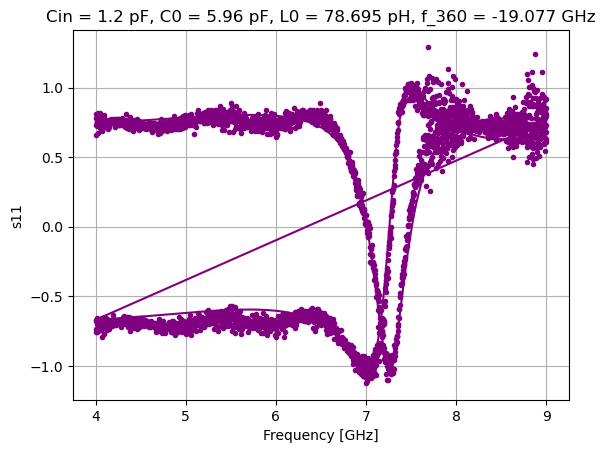

In [190]:
popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, unwrapped_s_ri_concat,p0=[Cinguess,C0guess,L0guess,f0ghz_360_theory],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,2*f0ghz_360_theory),(1.2*Cinguess,1.2*C0guess,3*L0guess,0.8*f0ghz_360_theory)))
plt.plot(fghzfghz,jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),color="purple")
plt.plot(fghzfghz,unwrapped_s_ri_concat,".",color="purple")
plt.grid()
#plt.xlim(4,8)
plt.xlabel("Frequency [GHz]")
plt.ylabel("s11")
plt.title('Cin = ' + str(np.round(popt[0],3)) + ' pF, C0 = ' + str(np.round(popt[1],3)) + ' pF, L0 = ' + str(np.round(popt[2],3)) + ' pH, f_360 = '  + str(np.round(popt[3],3)) + ' GHz')

Text(0.5, 1.0, 'Cin = 1.2 pF, C0 = 6.24 pF, L0 = 55.948 pH, f_360 = -19.075 GHz')

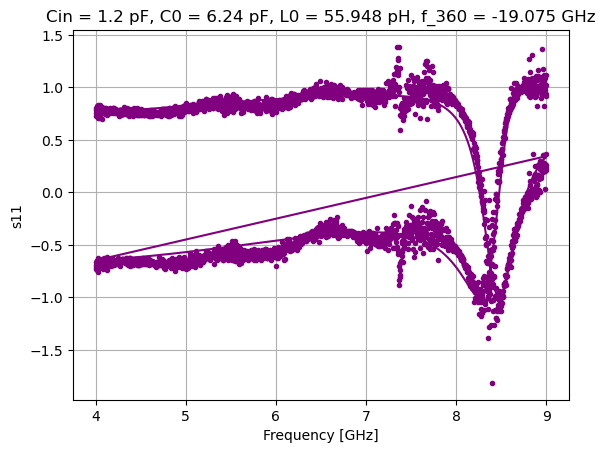

In [334]:
f0ghz_360_data = 2.3
unwrapped_s = np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace200'].s[:,0,0]
unwrapped_s_ri_concat = np.concatenate((np.real(unwrapped_s),np.imag(unwrapped_s)))
popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, unwrapped_s_ri_concat,p0=[Cinguess,C0guess,80,f0ghz_360_theory],bounds=((0.4*Cinguess,0.4*C0guess,0.1*L0guess,2*f0ghz_360_theory),(1.2*Cinguess,1.2*C0guess,5*L0guess,0.8*f0ghz_360_theory)))
plt.plot(fghzfghz,jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),color="purple")
plt.plot(fghzfghz,unwrapped_s_ri_concat,".",color="purple")
plt.grid()
#plt.xlim(4,8)
plt.xlabel("Frequency [GHz]")
plt.ylabel("s11")
plt.title('Cin = ' + str(np.round(popt[0],3)) + ' pF, C0 = ' + str(np.round(popt[1],3)) + ' pF, L0 = ' + str(np.round(popt[2],3)) + ' pH, f_360 = '  + str(np.round(popt[3],3)) + ' GHz')

In [264]:
realxy = []
for index in range(len(data_corrected)):
    realxy.append(np.real(np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace'+ str(index)].s[:,0,0]))
realxy = np.array(realxy)


In [272]:
imagxy = []
for index in range(len(data_corrected)):
    imagxy.append(np.imag(np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace'+ str(index)].s[:,0,0]))
imagxy = np.array(imagxy)

In [346]:
xy_concat = []
for index in range(len(data_corrected)):
    concatenated = np.concatenate((np.real(np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace'+ str(index)].s[:,0,0]),np.imag(np.exp(1j*2*np.pi*fghz/f0ghz_360_data)*data_corrected['trace'+ str(index)].s[:,0,0])))
    xy_concat.append(concatenated)
xy_concat = np.array(xy_concat)

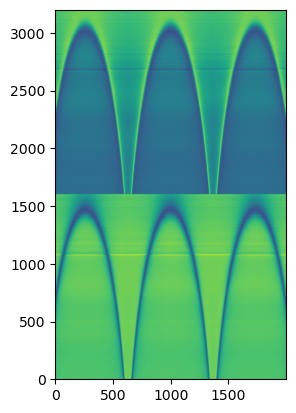

In [348]:
plt.imshow(xy_concat.transpose(),origin='lower')

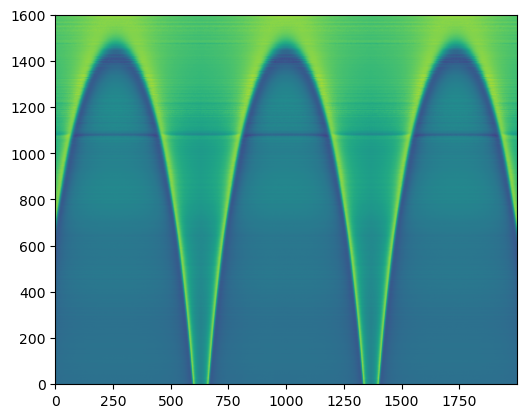

In [274]:
plt.imshow(imagxy.transpose(),origin='lower')

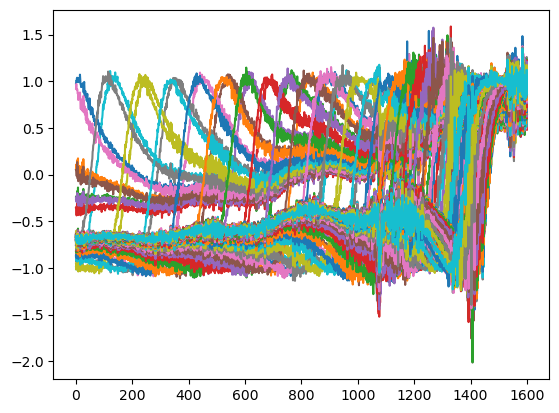

In [286]:
for index in range(100):
    plt.plot(imagxy[100+ 10*index])

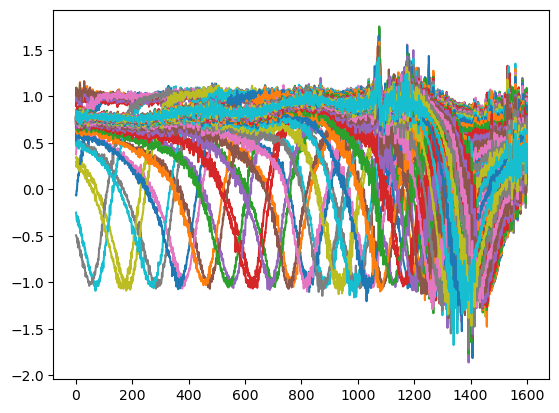

In [288]:
for index in range(100):
    plt.plot(realxy[100+ 10*index])

In [290]:
realxy[500]

array([0.71807165, 0.74569669, 0.67827368, ..., 0.76531277, 0.91108202,
       0.61527879])

In [300]:
np.argmin(realxy[500])

827

In [296]:
len(realxy[500])

1601

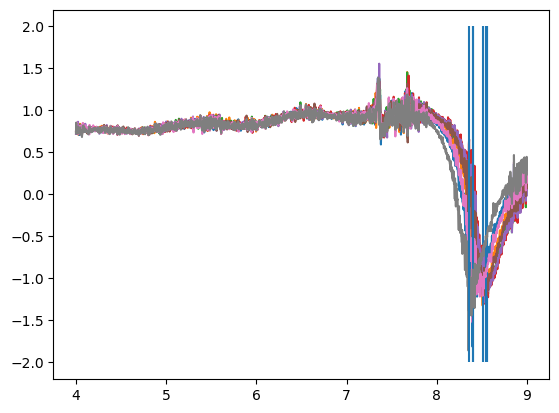

In [332]:
for index in range(8):
    plt.plot(fghz,realxy[200 + index*20])
    plt.vlines([fghz[np.argmin(realxy[200 + index*20])]],-2,2)


In [340]:
f_resonance = []
for index in range(len(realxy)):
    f_resonance.append(fghz[np.argmin(realxy[index])])


C:\Users\lfs\AppData\Local\Temp\1\ipykernel_15440\4240406456.py:2: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(phiwave,8.54*np.sqrt(0.1*np.cos(2*np.pi*phiwave)))


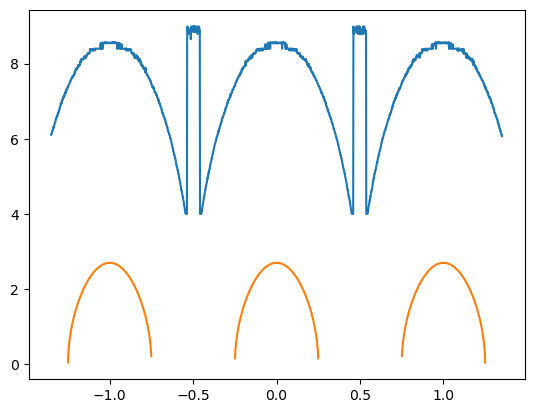

In [374]:
plt.plot(phiwave,f_resonance)
plt.plot(phiwave,8.54*np.sqrt(0.1*np.cos(2*np.pi*phiwave)))

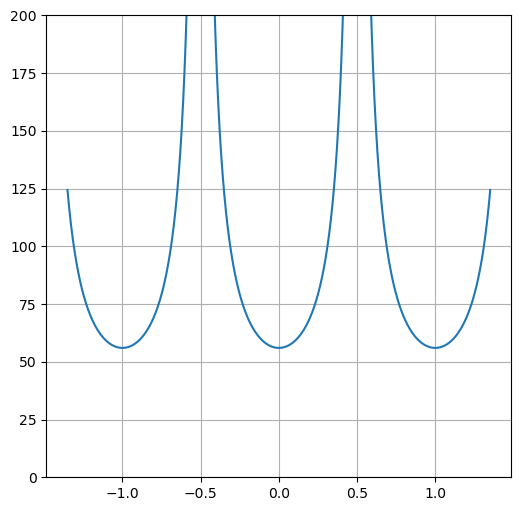

In [450]:
plt.figure(figsize=(6,6))
plt.plot(phiwave,56/np.abs(np.cos(np.pi*phiwave)))
plt.ylim(0,200)
plt.grid()

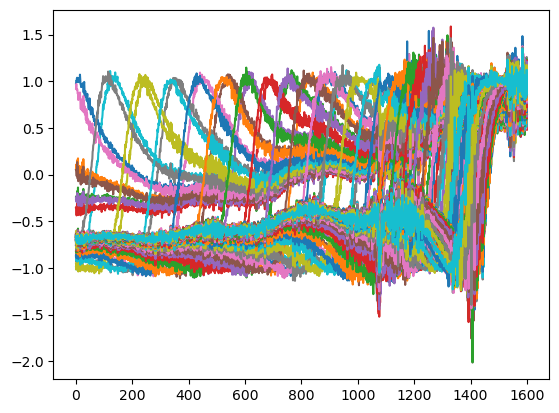

In [388]:
for index in range(100):
    plt.plot(imagxy[100 + 10*index])

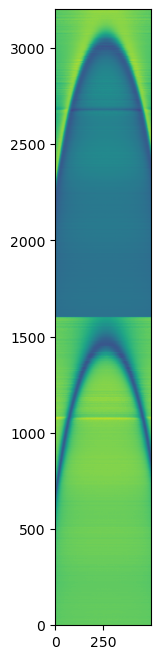

In [424]:
plt.figure(figsize=(20, 8))
plt.imshow(xy_concat[0:500].transpose(),origin='lower')
#plt.rcParams["figure.figsize"] = (20,3)

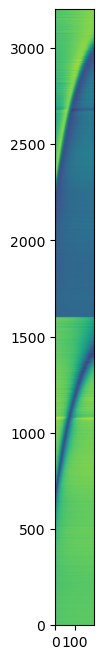

In [602]:
plt.figure(figsize=(20, 8))
plt.imshow(xy_concat[0:200].transpose(),origin='lower')
#plt.rcParams["figure.figsize"] = (20,3)

In [452]:
Lguesswave = 56/np.abs(np.cos(np.pi*phiwave))

In [562]:
Cinguess = 1.5
C0guess = 6
f0ghz_360_theory = -18
Cinwave = []
C0wave = []
L0wave = []
fghz_360wave = [] 

Cinsigmawave = []
C0sigmawave = []
L0sigmawave = []
fghz_360sigmawave = [] 


for index in range(200):
    popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, xy_concat[index],p0=[Cinguess,C0guess,Lguesswave[index],f0ghz_360_theory],bounds=((0.4, 2.08, 8.8, -42),(2, 10, 440, -16.8)))
    Cinwave.append(popt[0])
    C0wave.append(popt[1])
    L0wave.append(popt[2])
    fghz_360wave.append(popt[3])    
    Cinsigmawave.append(np.sqrt(pcov[0,0]))
    C0sigmawave.append(np.sqrt(pcov[1,1]))
    L0sigmawave.append(np.sqrt(pcov[2,2]))
    fghz_360sigmawave.append(np.sqrt(pcov[3,3]))


In [563]:
Cinwave = np.array(Cinwave)
C0wave = np.array(C0wave)
L0wave = np.array(L0wave)
fghz_360wave = np.array(fghz_360wave)
Cinsigmawave = np.array(Cinsigmawave)
C0sigmawave = np.array(C0sigmawave)
L0sigmawave = np.array(L0sigmawave)
fghz_360sigmawave = np.array(fghz_360sigmawave)


Text(0.5, 0, 'flux bias [per flux quantum]')

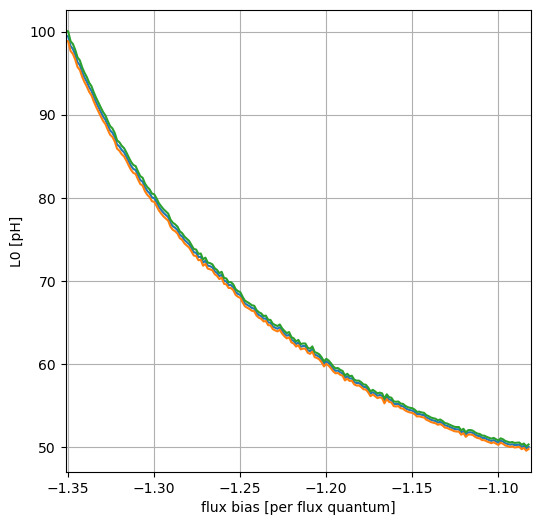

In [776]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],L0wave)
plt.plot(phiwave[0:200],L0wave - L0sigmawave)
plt.plot(phiwave[0:200],L0wave + L0sigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('L0 [pH]')
plt.xlabel('flux bias [per flux quantum]')

In [796]:
polyterms = np.polyfit(phiwave[0:200],L0wave,5)

In [798]:
polyterms

array([ -40982.69569888, -237041.53070804, -548052.23656373,
       -632707.99675787, -364572.94295824,  -83810.91231043])

Text(0.5, 0, 'flux bias [per flux quantum]')

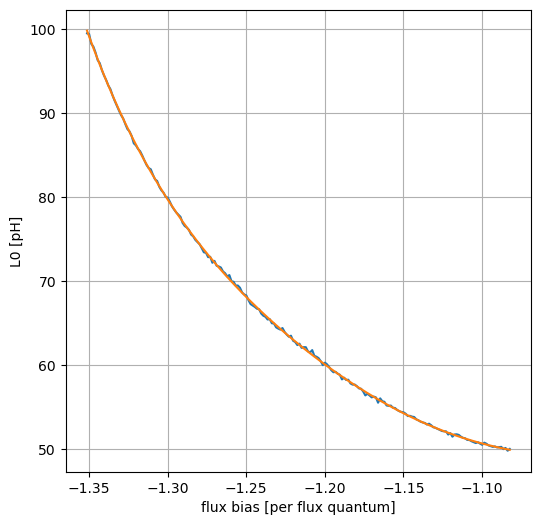

In [810]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],L0wave)
polyterms = np.polyfit(phiwave[0:200],L0wave,5)
Lpoly = polyterms[0]*phiwave[0:200]**5 + polyterms[1]*phiwave[0:200]**4 +polyterms[2]*phiwave[0:200]**3 +polyterms[3]*phiwave[0:200]**2 + polyterms[4]*phiwave[0:200] + polyterms[5]
plt.plot(phiwave[0:200],Lpoly)
plt.grid()
#plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('L0 [pH]')
plt.xlabel('flux bias [per flux quantum]')


Text(0.5, 1.0, 'line is at 1.565 pF')

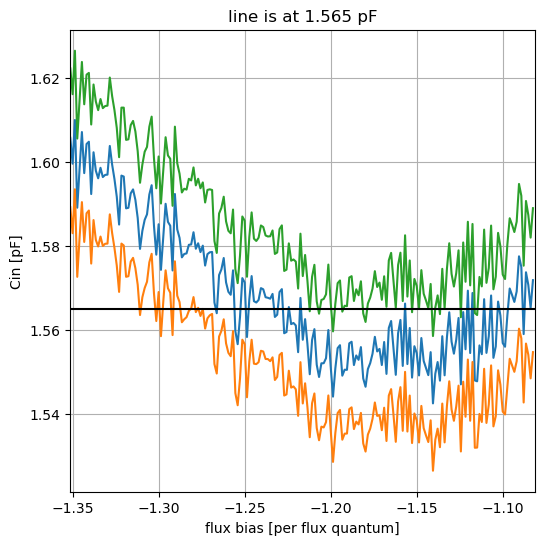

In [584]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],Cinwave)
plt.plot(phiwave[0:200],Cinwave  -Cinsigmawave)
plt.plot(phiwave[0:200],Cinwave +Cinsigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('Cin [pF]')
plt.xlabel('flux bias [per flux quantum]')
plt.hlines([1.565],phiwave[0],phiwave[200],color="black")
plt.title('line is at 1.565 pF')

Text(0.5, 0, 'flux bias [per flux quantum]')

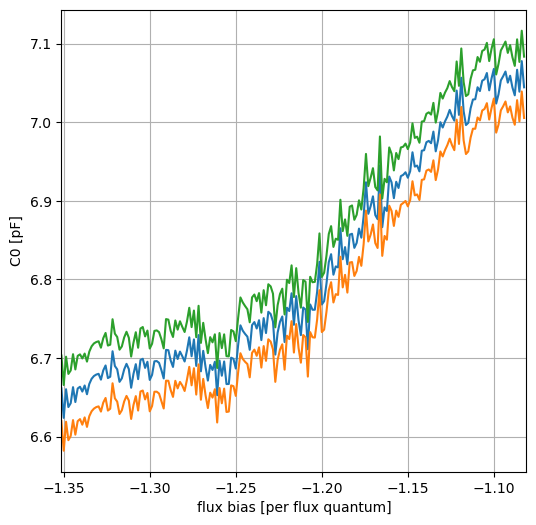

In [574]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],C0wave)
plt.plot(phiwave[0:200],C0wave  - C0sigmawave)
plt.plot(phiwave[0:200],C0wave +  C0sigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('C0 [pF]')
plt.xlabel('flux bias [per flux quantum]')

Text(0.5, 1.0, 'line is at -17.63 GHz')

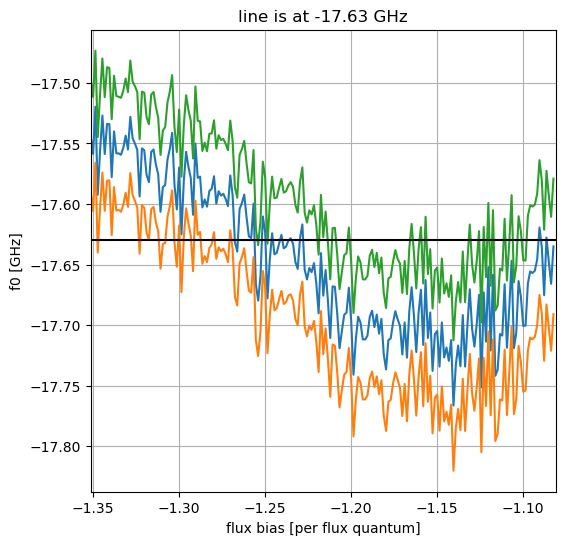

In [586]:
fig = plt.figure(figsize=(6, 6))

plt.plot(phiwave[0:200],fghz_360wave)
plt.plot(phiwave[0:200],fghz_360wave  - fghz_360sigmawave)
plt.plot(phiwave[0:200],fghz_360wave +  fghz_360sigmawave)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('f0 [GHz]')
plt.xlabel('flux bias [per flux quantum]')

plt.hlines([-17.63],phiwave[0],phiwave[200],color="black")
plt.title('line is at -17.63 GHz')

In [590]:
Cinguess = 1.565
C0guess = 6.8
f0ghz_360_theory = -17.63
Cinwave2 = []
C0wave2 = []
L0wave2 = []
fghz_360wave2 = [] 

Cinsigmawave2 = []
C0sigmawave2 = []
L0sigmawave2 = []
fghz_360sigmawave2 = [] 


for index in range(200):
    popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, xy_concat[index],p0=[Cinguess,C0guess,Lguesswave[index],f0ghz_360_theory],bounds=((Cinguess - 0.001, C0guess - 0.001, 8.8, f0ghz_360_theory - 0.01),(Cinguess + 0.001, C0guess + 0.001, 440, f0ghz_360_theory + 0.01)))
    Cinwave2.append(popt[0])
    C0wave2.append(popt[1])
    L0wave2.append(popt[2])
    fghz_360wave2.append(popt[3])    
    Cinsigmawave2.append(np.sqrt(pcov[0,0]))
    C0sigmawave2.append(np.sqrt(pcov[1,1]))
    L0sigmawave2.append(np.sqrt(pcov[2,2]))
    fghz_360sigmawave2.append(np.sqrt(pcov[3,3]))


In [594]:
Cinwave2 = np.array(Cinwave2)
C0wave2 = np.array(C0wave2)
L0wave2 = np.array(L0wave2)
fghz_360wave2 = np.array(fghz_360wave2)
Cinsigmawave2 = np.array(Cinsigmawave2)
C0sigmawave2 = np.array(C0sigmawave2)
L0sigmawave2 = np.array(L0sigmawave2)
fghz_360sigmawave2 = np.array(fghz_360sigmawave2)

Text(0.5, 0, 'flux bias [per flux quantum]')

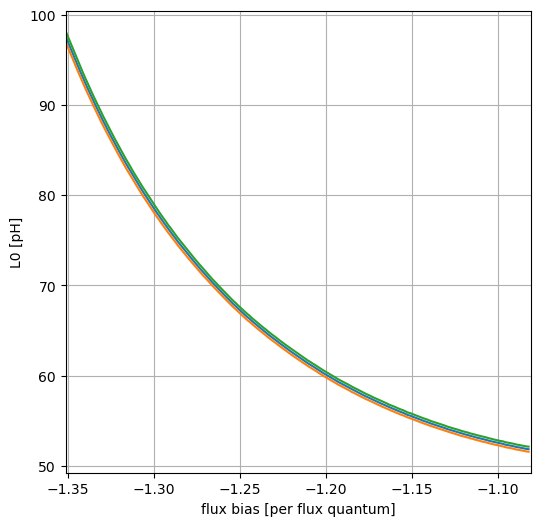

In [596]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],L0wave2)
plt.plot(phiwave[0:200],L0wave2 - L0sigmawave2)
plt.plot(phiwave[0:200],L0wave2 + L0sigmawave2)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('L0 [pH]')
plt.xlabel('flux bias [per flux quantum]')

Text(0.5, 1.0, 'line is at 1.565 pF')

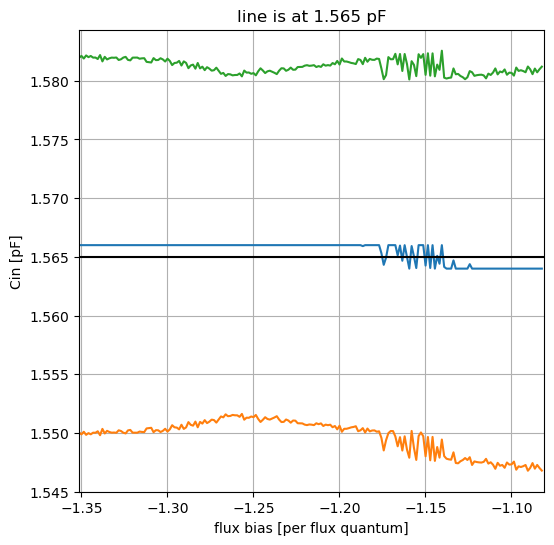

In [598]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],Cinwave2)
plt.plot(phiwave[0:200],Cinwave2  -Cinsigmawave2)
plt.plot(phiwave[0:200],Cinwave2 +Cinsigmawave2)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('Cin [pF]')
plt.xlabel('flux bias [per flux quantum]')
plt.hlines([1.565],phiwave[0],phiwave[200],color="black")
plt.title('line is at 1.565 pF')

Text(0.5, 0, 'flux bias [per flux quantum]')

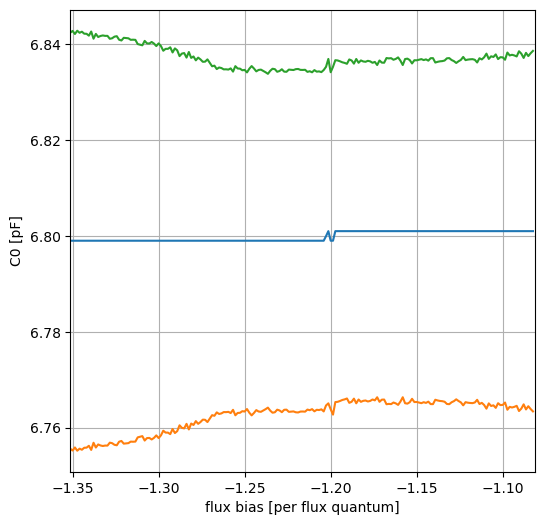

In [600]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],C0wave2)
plt.plot(phiwave[0:200],C0wave2  - C0sigmawave2)
plt.plot(phiwave[0:200],C0wave2 +  C0sigmawave2)
plt.grid()
plt.xlim(phiwave[0],phiwave[200])
plt.ylabel('C0 [pF]')
plt.xlabel('flux bias [per flux quantum]')

(6.0, 8.0)

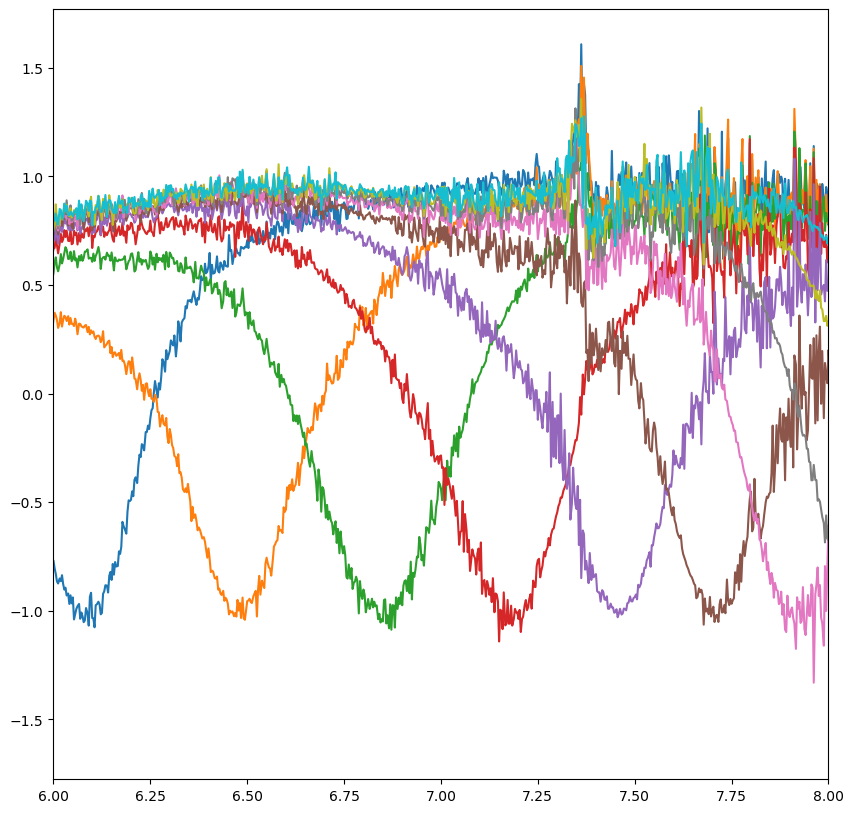

In [636]:
for index in range(10):
    plt.plot(fghz,realxy[20*index])
plt.xlim(6,8)

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lfs\AppData\Local\Temp\1\ipykernel_15440\1573202538.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$\phi/\phi_0$')


Text(0, 0.5, 's11')

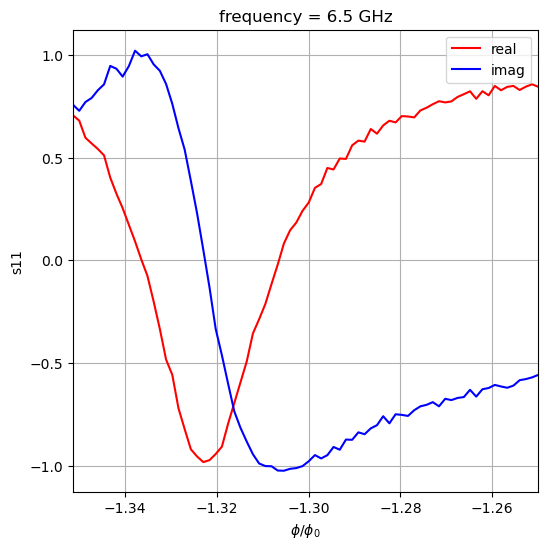

In [678]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],realxy.transpose()[800][0:200],color="red")
plt.plot(phiwave[0:200],imagxy.transpose()[800][0:200],color="blue")
plt.title("frequency = " + str(fghz[800]) + " GHz")
plt.xlim(phiwave[0],phiwave[200])
plt.grid()
plt.legend(["real","imag"])
plt.xlim(phiwave[0],-1.25)
plt.xlabel('$\phi/\phi_0$')
plt.ylabel('s11')

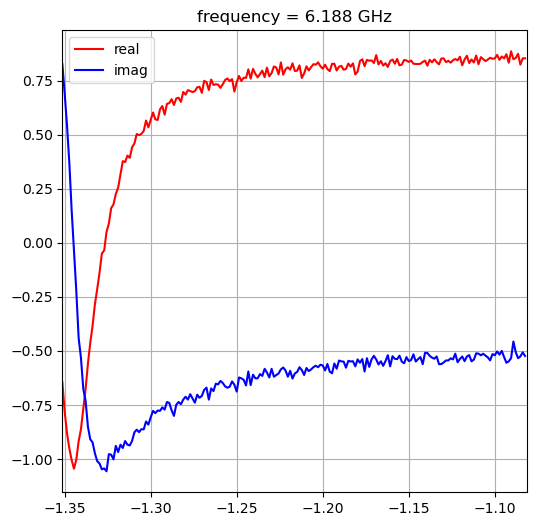

In [662]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],realxy.transpose()[700][0:200],color="red")
plt.plot(phiwave[0:200],imagxy.transpose()[700][0:200],color="blue")
plt.title("frequency = " + str(fghz[700]) + " GHz")
plt.xlim(phiwave[0],phiwave[200])
plt.grid()
plt.legend(["real","imag"])

Text(0, 0.5, 's11')

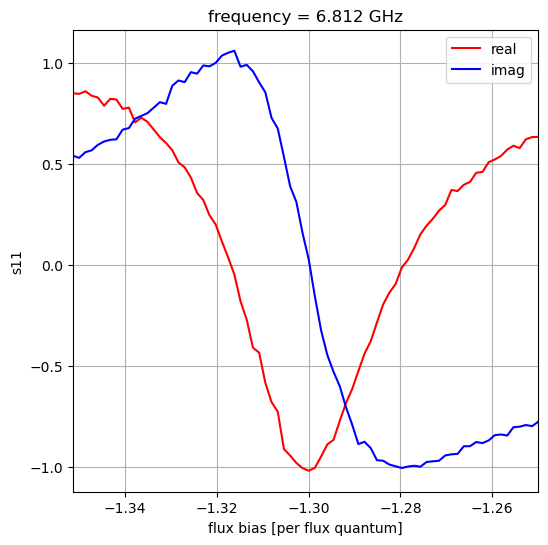

In [812]:
fig = plt.figure(figsize=(6, 6))
plt.plot(phiwave[0:200],realxy.transpose()[900][0:200],color="red")
plt.plot(phiwave[0:200],imagxy.transpose()[900][0:200],color="blue")
plt.title("frequency = " + str(fghz[900]) + " GHz")
plt.xlim(phiwave[0],-1.25)
plt.grid()
plt.legend(["real","imag"])
plt.xlabel('flux bias [per flux quantum]')
plt.ylabel('s11')

In [712]:
def jpa_fixed(frequencyghz, phi):
    Cinlocal = 1.565e-12
    C0local = 6.8e-12
    L0local = 5.5e-12 + 44.1e-12/np.abs(np.cos(np.pi*phi))
    taulocal = 56.72e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cinlocal)) + (1j*omega*L0local)/(1 - omega*omega*C0local*L0local)
    s_jpa = (50 - Z_jpa)/(50 + Z_jpa)
    s_jpa = -s_jpa*np.exp(-1j*omega*taulocal)
    return s_jpa

In [746]:
len(realxy[0])

1601

Text(0, 0.5, 's11')

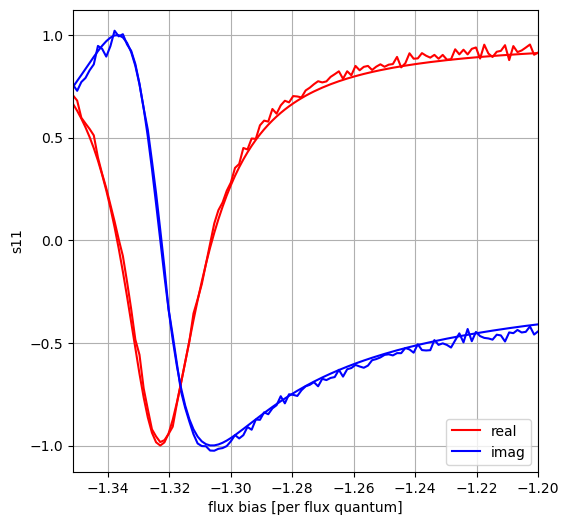

In [854]:

def jpa_fixed(frequencyghz, phi):
    Cinlocal = 1.565e-12
    C0local = 6.7e-12
    L0local = 1e-12*(polyterms[0]*phi**5 + polyterms[1]*phi**4 +polyterms[2]*phi**3 +polyterms[3]*phi**2 + polyterms[4]*phi + polyterms[5])

    taulocal = 56.72e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cinlocal)) + (1j*omega*L0local)/(1 - omega*omega*C0local*L0local)
    s_jpa = (50 - Z_jpa)/(50 + Z_jpa)
    s_jpa = s_jpa*np.exp(-1j*(omega*taulocal))
    s_jpa = s_jpa*np.exp(1j*(np.pi/2)) # why is this here? i added this randomly because it worked. i don't understand it.
    return s_jpa

fig = plt.figure(figsize=(6, 6))
findex = 800
plt.plot(phiwave[0:200],realxy.transpose()[findex][0:200],color="red")
plt.plot(phiwave[0:200],imagxy.transpose()[findex][0:200],color="blue")
plt.plot(phiwave[0:200],np.real(jpa_fixed(fghz[findex],phiwave[0:200])),color="red")
plt.plot(phiwave[0:200],np.imag(jpa_fixed(fghz[findex],phiwave[0:200])),color="blue")

plt.plot()
plt.xlim(phiwave[0],-1.2)
plt.grid()
plt.legend(["real","imag"])
plt.xlabel('flux bias [per flux quantum]')
plt.ylabel('s11')

Text(0, 0.5, 's11')

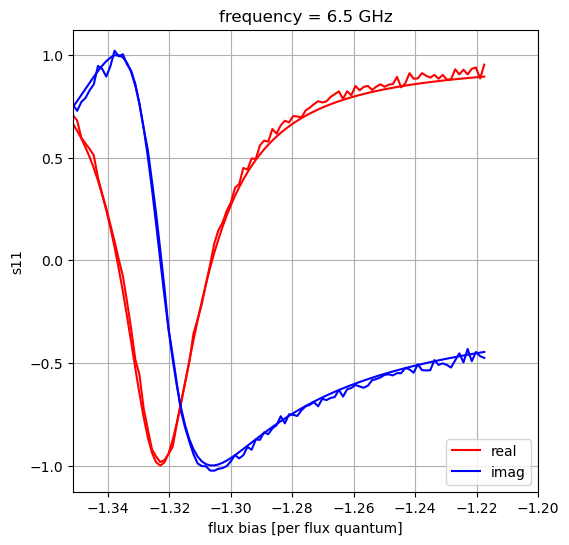

In [964]:
fig = plt.figure(figsize=(6, 6))
findex = 800
plt.plot(phiwave[0:100],realxy.transpose()[findex][0:100],color="red")
plt.plot(phiwave[0:100],imagxy.transpose()[findex][0:100],color="blue")
plt.plot(phiwave[0:100],np.real(jpa_fixed(fghz[findex],phiwave[0:100])),color="red")
plt.plot(phiwave[0:100],np.imag(jpa_fixed(fghz[findex],phiwave[0:100])),color="blue")
plt.title("frequency = " + str(fghz[findex]) + " GHz")

plt.plot()
plt.xlim(phiwave[0],-1.2)
plt.grid()
plt.legend(["real","imag"])
plt.xlabel('flux bias [per flux quantum]')
plt.ylabel('s11')

<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lfs\AppData\Local\Temp\1\ipykernel_15440\2922232378.py:18: SyntaxWarning: invalid escape sequence '\p'
  plt.title("frequency = " + str(fghz[findex]) + " GHz\n$\phi/\phi_0$ = " + str(np.round(phiwave[phiindex1],3)) + ", " + str(np.round(phiwave[phiindex2],3)) + ", " + str(np.round(phiwave[phiindex3],3)))


Text(0, 0.5, 'Imag[s11]')

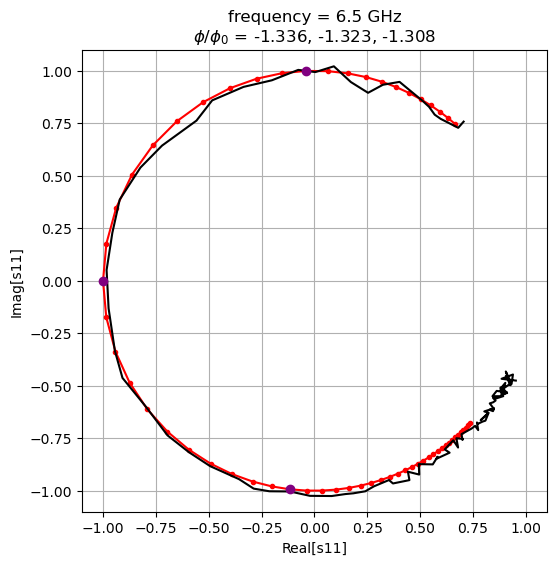

In [974]:
fig = plt.figure(figsize=(6, 6))
findex = 800
startindex = 0
stopindex = 60
plt.plot(np.real(jpa_fixed(fghz[findex],phiwave[startindex:stopindex])),np.imag(jpa_fixed(fghz[findex],phiwave[startindex:stopindex])),color="red",marker=".")

plt.plot()
#plt.xlim(phiwave[0],-1.2)
plt.grid()
#plt.legend(["real","imag"])
#plt.xlabel('flux bias [per flux quantum]')
plt.Circle((0, 0), 0.2, color='r')
plt.xlim([-1.1,1.1])
plt.ylim([-1.1,1.1])
phiindex1 = 11
phiindex2 = 21
phiindex3 = 32
plt.title("frequency = " + str(fghz[findex]) + " GHz\n$\phi/\phi_0$ = " + str(np.round(phiwave[phiindex1],3)) + ", " + str(np.round(phiwave[phiindex2],3)) + ", " + str(np.round(phiwave[phiindex3],3)))


plt.plot(realxy.transpose()[findex][0:100],imagxy.transpose()[findex][0:100],color="black")

plt.plot(np.real(jpa_fixed(fghz[findex],phiwave[phiindex1])),np.imag(jpa_fixed(fghz[findex],phiwave[phiindex1])),'o',color="purple")
plt.plot(np.real(jpa_fixed(fghz[findex],phiwave[phiindex2])),np.imag(jpa_fixed(fghz[findex],phiwave[phiindex2])),'o',color="purple")
plt.plot(np.real(jpa_fixed(fghz[findex],phiwave[phiindex3])),np.imag(jpa_fixed(fghz[findex],phiwave[phiindex3])),'o',color="purple")
plt.xlabel('Real[s11]')
plt.ylabel('Imag[s11]')


In [982]:
top_data = realxy.transpose()[findex][phiindex1] + 1j*imagxy.transpose()[findex][phiindex1]
left_data = realxy.transpose()[findex][phiindex2] + 1j*imagxy.transpose()[findex][phiindex2]
bottom_data = realxy.transpose()[findex][phiindex3] + 1j*imagxy.transpose()[findex][phiindex3]

In [1006]:
s_top_data = np.array([top_data])

In [1010]:
middlefreq = Frequency(6.5,6.5,1,unit='GHz')

In [1030]:
top_measured    = rf.Network(frequency = middlefreq,s = top_data)
left_measured   = rf.Network(frequency = middlefreq,s = left_data)
bottom_measured = rf.Network(frequency = middlefreq,s = bottom_data)


In [1032]:
my_measured = [\
        top_measured,
        left_measured,
        bottom_measured,
]

In [1046]:
top_ideal_s = np.real(jpa_fixed(fghz[findex],phiwave[phiindex1])) + 1j*np.imag(jpa_fixed(fghz[findex],phiwave[phiindex1]))
left_ideal_s = np.real(jpa_fixed(fghz[findex],phiwave[phiindex2])) + 1j*np.imag(jpa_fixed(fghz[findex],phiwave[phiindex2]))
bottom_ideal_s = np.real(jpa_fixed(fghz[findex],phiwave[phiindex3])) + 1j*np.imag(jpa_fixed(fghz[findex],phiwave[phiindex3]))


In [1048]:
top_ideal    = rf.Network(frequency = middlefreq,s = top_ideal_s)
left_ideal   = rf.Network(frequency = middlefreq,s = left_ideal_s)
bottom_ideal = rf.Network(frequency = middlefreq,s = bottom_ideal_s)


In [1050]:
my_ideals = [\
        top_ideal,
        left_ideal,
        bottom_ideal,
]

In [1052]:
cal_middle = rf.OnePort(\
        ideals = my_ideals,
        measured = my_measured,
        )

In [1054]:
cal_middle.run()

In [1067]:
cal_middle.coefs

{'directivity': array([0.02131595+0.01097857j]),
 'reflection tracking': array([1.00246151-0.01950659j]),
 'source match': array([-0.00285338+0.02039956j])}